In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xobjects as xo
import matplotlib.pyplot as plt

import numpy as np

### Compute multi-species ratios

In [3]:
# Create particles
p0_car = xt.Particles('Carbon-12')
p0_hel = xt.Particles('Helium-4')

In [4]:
mass_ratio_hel_car = p0_hel.mass0 / p0_car.mass0
charge_ratio_hel_car = p0_hel.q0 / p0_car.q0
chi_hel = charge_ratio_hel_car / mass_ratio_hel_car

### Load the line

In [5]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')
line = env.ring
# Use a slightly simplified model for tracking speed:
line.configure_bend_model(num_multipole_kicks=5)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

### Insert extraction septum aperture

In [6]:
env.new('extr_septum', xt.Marker)
env.new('septum_aperture', xt.LimitRect, min_x=-0.035, max_x=0.1, min_y=-0.1, max_y=0.1)

line.insert(['extr_septum', 'septum_aperture'], at=0)

Slicing line:   0%|          | 0/109 [00:00<?, ?it/s]

### Set Carbon at 200 MeV / nucleon as reference particle

In [7]:
line.set_particle_ref('Carbon-12', kinetic_energy0=200e6 * 12)

tw = line.twiss4d()

### Configure machine for slow extraction

In [8]:
# Qx close to resonance
env['tune_x'] = 1.665

# Extraction sextupole ON
env['kse'] = 3.

# Zero chromaticity
env['chrom_x'] = 0
env['chrom_y'] = 0

In [9]:
tw = line.twiss4d()
print(f"Qx={tw.qx:.4f}, Q'x={tw.dqx:.3f}, Q'y={tw.dqy:.3f}")

Qx=1.6650, Q'x=-0.002, Q'y=-0.005


### Compute expected momentum difference

In [10]:
# As before:
alpha = tw.momentum_compaction_factor
eta = tw.slip_factor
delta_diff_expected = alpha / eta * (chi_hel - 1)

### Define time-dependent behavior of extraction sextupole

In [11]:
# Linear increase between 0.1 ms and 0.5 ms, then constant
line.functions['fun_xsext'] = xt.FunctionPieceWiseLinear(x=[0, 0.1e-3, 0.5e-3], y=[0, 0, 1.])
line.ref['kse'] *= line.functions['fun_xsext'](line.vars['t_turn_s'])

# Inspect the expression
line.ref['kse']._expr

(3.0 * f['fun_xsext'](vars['t_turn_s']))

### Introduce transverse excitation to control the spill

In [12]:
num_turns = 5000

We apply a Guassian noise changing 8 times per turn

In [13]:
samples_per_turn = 8

# Allow ten turns of margin for arrival-time offsets at either end.
noise_samples = np.random.normal(size=num_turns * samples_per_turn)

# Normalize
noise_samples -= noise_samples.mean()
noise_samples /= noise_samples.std()

# Create an exciter object
env.elements['spill_excit'] = xt.Exciter(
    samples=noise_samples,
    sampling_frequency=samples_per_turn / tw.t_rev0,
    frev=1 / tw.t_rev0,
    start_turn=-10,
    knl=[0.] # Will set the strength later
)

line.insert('spill_excit', at=0)

Slicing line:   0%|          | 0/111 [00:00<?, ?it/s]

In [14]:
# Control the exciter with a time dependent function
line.functions['fun_excit'] = xt.FunctionPieceWiseLinear(
    x=[0, 0.5e-3, 0.6e-3,    1e-3],
    y=[0, 0,       1.2e-5,   1.2e-5])

line.vars['ampl_excit'] = line.functions['fun_excit'](line.ref['t_turn_s'])
# Exciter uses the multipole convention: delta_px = -chi * knl[0] * sample.
line['spill_excit'].knl[0] = -env.ref['ampl_excit']

### Generate beam with the two species in the same particle object
We assume the two species to have different horizontal emittance

In [15]:
nemitt_x_car = 1.00e-6
nemitt_x_hel = 0.05e-6

Generate Carbon Gaussian beam (de-bunched)

In [16]:
np.random.seed(12345)

num_particles = 1000
beam_intensity = 1e10 # p+

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution (rms spread 5e-4)
delta = 5e-4 * np.random.normal(size=num_particles)

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_carbon = line.build_particles(
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=nemitt_x_car, nemitt_y=1e-6,
)

Generate Helium Gaussian beam (de-bunched)

In [17]:
num_particles = 1000
beam_intensity = 1e10 

# Generate Gaussian distribution in normalized phase space
x_norm = np.random.normal(size=num_particles)
px_norm = np.random.normal(size=num_particles)
y_norm = np.random.normal(size=num_particles)
py_norm = np.random.normal(size=num_particles)

# Generate Gaussian momentum distribution ** with the right energy shift **
delta = 5e-4 * np.random.normal(size=num_particles) + delta_diff_expected 

# Particles arrival time spread over one turn
zeta = np.random.uniform(size=num_particles) * line.get_length()

# Assemble Particles object
p0_helium = line.build_particles(
    mass_ratio=mass_ratio_hel_car,
    charge_ratio=charge_ratio_hel_car,
    x_norm=x_norm, px_norm=px_norm, 
    y_norm=y_norm, py_norm=py_norm,
    delta=delta,
    zeta=zeta,
    method='4d',
    weight=beam_intensity / num_particles,
    nemitt_x=nemitt_x_hel,
    nemitt_y=1.e-6,
)

In [18]:
# Shift helium particle id to easily distingish the two
p0_helium.particle_id += 1_000_000 # To easily identify the two

In [19]:
# Merge the two Particles objects
p0 = xt.Particles.merge([p0_carbon, p0_helium])

In [20]:
# Inspect particle_id and mass_ratio
p0.particle_id

array([      0,       1,       2, ..., 1000997, 1000998, 1000999],
      shape=(2000,))

In [21]:
p0.mass_ratio

LinkedArrayCpu([1.        , 1.        , 1.        , ..., 0.33355031,
                0.33355031, 0.33355031], shape=(2000,))

### Install monitors to record the intensity of the two beams

In [22]:
env.elements['monitor_car'] = xt.BeamStatsMonitor(
    start_at_turn=0, stop_at_turn=num_turns,
    particle_id_range=(0, 10_000), # <- select ids used for carbon 
    stats=['num_particles'],
)

env.elements['monitor_hel'] = xt.BeamStatsMonitor(
    start_at_turn=0, stop_at_turn=num_turns,
    particle_id_range=(1_000_000, 1_010_000), # <- select ids used for helium 
    stats=['num_particles'],
)

line.insert(['monitor_hel', 'monitor_car'], at=0)

Slicing line:   0%|          | 0/112 [00:00<?, ?it/s]

### Track the mixed beam!

In [23]:
# Switch to multi-core mode
ctx = xo.ContextCpu(omp_num_threads='auto')
line.build_tracker(_context=ctx)

In [24]:
line.enable_time_dependent_vars = True # To enable time functions defined above

p = p0.copy()
line.track(p, num_turns=num_turns, with_progress=True,
           log=xt.Log('kse', 't_turn_s', 'ampl_excit'))

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

In [25]:
# Get recorded intensity for the two beams
int_carbon = line['monitor_car'].num_particles.copy()
int_helium = line['monitor_hel'].num_particles.copy()

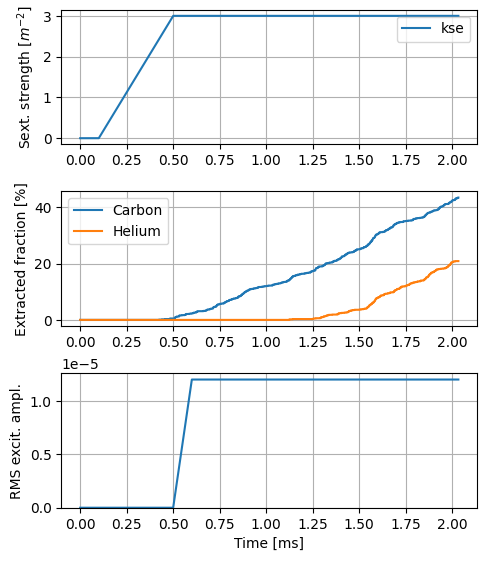

In [26]:
# Plot
plt.figure(figsize=(6.4, 6.0))

log = line.log_last_track # Logged variables
t_ms = np.array(log['t_turn_s']) * 1e3

ax1 = plt.subplot(3,1,1)
plt.plot(t_ms, log['kse'], label='kse')
plt.ylabel('Sext. strength [$m^{-2}$]')
plt.legend()
plt.grid()

ax2 = plt.subplot(3,1,2, sharex=ax1)
plt.plot(t_ms, 100 * (1 - int_carbon/int_carbon[0]), label='Carbon')
plt.plot(t_ms, 100 * (1 - int_helium/int_helium[0]), label='Helium')
plt.ylabel('Extracted fraction [%]')
plt.legend()
plt.grid()

ax3 = plt.subplot(3,1,3, sharex=ax1)
plt.plot(t_ms, log['ampl_excit'])
plt.ylim(bottom=0)
plt.ylabel('RMS excit. ampl.')
plt.xlabel('Time [ms]')
plt.grid()

plt.subplots_adjust(top=.93, bottom=.1, left=.25, hspace=.35)

### Use chromaticity to synchronize extractio of the two beams

For zero chromaticity, the helium beam (having smaller emittance) starts being extracted much later.
We can explolit our earlier observation that for positive chromaticity the Helium gets closer to the resonance, to anticipate its extraction.

In [27]:
# Set Q'x = 1.0
env['chrom_x'] = 1.

In [28]:
# Reset time-dependent variables and monitors
env['t_turn_s'] = 0 
env['monitor_car'].clear()
env['monitor_hel'].clear()

In [ ]:
# Track again
p = p0.copy()
line.track(p, num_turns=num_turns, with_progress=True,
           log=xt.Log('kse', 't_turn_s', 'ampl_excit'))

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
# Plot
plt.figure(figsize=(6.4, 6.0))

log = line.log_last_track # Logged variables
t_ms = np.array(log['t_turn_s']) * 1e3

ax1 = plt.subplot(3,1,1)
plt.plot(t_ms, log['kse'], label='kse')
plt.ylabel('Sext. strength [$m^{-2}$]')
plt.legend()
plt.grid()

ax2 = plt.subplot(3,1,2, sharex=ax1)
plt.plot(t_ms, 100 * (1 - int_carbon/int_carbon[0]), label='Carbon')
plt.plot(t_ms, 100 * (1 - int_helium/int_helium[0]), label='Helium')
plt.ylabel('Extracted fraction [%]')
plt.legend()
plt.grid()

ax3 = plt.subplot(3,1,3, sharex=ax1)
plt.plot(t_ms, log['ampl_excit'])
plt.ylim(bottom=0)
plt.ylabel('RMS excit. ampl.')
plt.xlabel('Time [ms]')
plt.grid()

plt.subplots_adjust(top=.93, bottom=.1, left=.25, hspace=.35)